<a href="https://colab.research.google.com/github/sharkbyte-x/North-American-Deforestation-Data-Analysis-2001---2024-Hack-the-Hood-Final-Project-/blob/main/North_American_Deforestation_Data_Analysis_(2001_2024)_by_Kenny_Solorio_%5BHack_the_Hood_Final_Project%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# North American Deforestation Data Analysis (2001 - 2024)

---


## [Hack the Hood Final Project]
## by Kenny Solorio

**Dataset:** https://gfw.global/44u3kaZ



> Explore interactive charts and maps that summarize global rates of forest change.Statistics – including rankings of countries with the most forest loss and gain, and drivers of deforestation –
can be customized, easily shared and downloaded for offline use. Download global statistics by country here:
https://gfw2-data.s3.amazonaws.com/country-pages/country_stats/download/2024/global_05212025.xlsx

**Objective:**

I am analyzing a dataset by Global Forest Watch that has compiled the global statistics on Forest Change in the past 20+ years. I chose this dataset because I wanted my analysis to help communities, nonprofits, and agencies in understanding how deforestation in North America has been impacted by social and natural factors known as 'Main Drivers'.

In addition, I wanted to showcase how Machine Learning could help predict forest loss by Main Driver and intervention could then be made once the data and predictions have been analyzed.

**Research Questions:**
1. What are the main drivers of deforestation and tree cover loss in the North American Countries of Canada, U.S.A., and Mexico?

2. How do the deforestation trends of these drivers for each country compare to each other?

3. What are each North American Countries Main Drivers in Deforestation from 2001 - 2024?

4. Can we accurately predict tree cover loss in North America by year?

5. Can we accurately predict future wildfires as a main driver in tree cover loss?

In the following Notebook I will walk you through my findings on Deforestation trends, predictions, and analysis in North American Countries.

# Part 1: Setting up the environment for Data Analysis of North American Deforestation Trends

In [ ]:
#Setting up Libraries
!pip install openpyxl
import pandas as pd

In [ ]:
#Importing Datasets
tcl = pd.read_excel('global_05212025.xlsx', sheet_name='Country tree cover loss') #Country tree cover loss data sheet
#Country Tree Cover Loss: Hectares of tree cover loss at a national level, between 2001-2024, categorized by percent canopy cover in 2000.

tfl = pd.read_excel('global_05212025.xlsx', sheet_name='Country primary loss') #Country primary loss datasheet // Tropical forest loss data
#Country primary loss: Hectares of humid tropical primary forest loss at a national level, between 2002-2024, at 30% tree canopy density only.

cdr = pd.read_excel('global_05212025.xlsx', sheet_name='Country drivers') #Country driver data sheet
#Country drivers: Hectares of tree cover loss at a national level, between 2001-2024, at 30% tree canopy density and categorized by dominant driver.
#Years correspond to the loss year of the annual tree cover loss data.

ccd = pd.read_excel('global_05212025.xlsx', sheet_name='Country carbon data') #Country carbon data datasheet
#Country carbon data: Aboveground woody biomass stocks and densities in 2000 (Mg AGB and Mg AGB/ha, respectively);
#average annual GHG emissions, removals (sequestration), and net flux between 2001 and 2024 (Mg CO2e/yr);
#annual GHG emissions (Mg CO2e). Provided by percent canopy cover in 2000 (>30%, 50%, and 75% only).



#Viewing Datasets
print('Tree Cover Loss DataFrame:')
print(tcl.info())

print('\nTropical Forest Loss DataFrame:')
print(tfl.info())

print('\nCountry Drivers DataFrame:')
print(cdr.info())

print('\nCountry Carbon Data DataFrame:')
print(ccd.info())

Tree Cover Loss DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   country            1328 non-null   object
 1   threshold          1328 non-null   int64 
 2   area_ha            1328 non-null   int64 
 3   extent_2000_ha     1328 non-null   int64 
 4   extent_2010_ha     1328 non-null   int64 
 5   gain_2000-2012_ha  1328 non-null   int64 
 6   tc_loss_ha_2001    1328 non-null   int64 
 7   tc_loss_ha_2002    1328 non-null   int64 
 8   tc_loss_ha_2003    1328 non-null   int64 
 9   tc_loss_ha_2004    1328 non-null   int64 
 10  tc_loss_ha_2005    1328 non-null   int64 
 11  tc_loss_ha_2006    1328 non-null   int64 
 12  tc_loss_ha_2007    1328 non-null   int64 
 13  tc_loss_ha_2008    1328 non-null   int64 
 14  tc_loss_ha_2009    1328 non-null   int64 
 15  tc_loss_ha_2010    1328 non-null   int64 
 16  tc_loss_ha_2011

After viewing what the dataframes in the dataset holds, I decide to use 'Country Drivers' as my main dataframe to base my analysis on.

Next I will filter the dataframe into 4 different dataframes that will help organize my analysis.

In [ ]:
#Filtering DataFrames by Country
#Canada
CAN_cdr = cdr[cdr['country'] == 'Canada']

#USA
USA_cdr = cdr[cdr['country'] == 'United States']

#Mexico
MEX_cdr = cdr[cdr['country'] == 'México']

#Filtering DataFrames by Countries in North America
#North America
NA_cdr = cdr[cdr['country'].isin(['Canada', 'United States', 'México'])]


In [ ]:
#Confirming Filtered DataFrames
NA_cdr.sample()

#Run this cell multiple times to confirm the df holds all three countries

,country,threshold,driver,year,tc_loss_ha
3303,Canada,30,Other natural disturbances,2016,21151.0


In [ ]:
#Data Cleaning
#Checking for Null Values
NA_cdr.isnull()
CAN_cdr.isnull()
USA_cdr.isnull()
MEX_cdr.isnull()
#There are no null values. Dataset imported is cleaned and organized already.

#Filling Null Values with 0 as a placeholder just in case
NA_cdr.fillna(0)
CAN_cdr.fillna(0)
USA_cdr.fillna(0)
MEX_cdr.fillna(0)

#Removing Duplicate Rows
NA_cdr.drop_duplicates()
CAN_cdr.drop_duplicates()
USA_cdr.drop_duplicates()
MEX_cdr.drop_duplicates()

,country,threshold,driver,year,tc_loss_ha
12481,México,30,Hard commodities,2001,542.0
12482,México,30,Hard commodities,2002,569.0
12483,México,30,Hard commodities,2003,467.0
12484,México,30,Hard commodities,2004,725.0
12485,México,30,Hard commodities,2005,903.0
...,...,...,...,...,...
12644,México,30,Wildfire,2020,45458.0
12645,México,30,Wildfire,2021,27339.0
12646,México,30,Wildfire,2022,20502.0
12647,México,30,Wildfire,2023,26717.0


# Part 2: Visualizing the Deforestation Trends by Main Driver and Country

driver
Hard commodities                  635387.0
Logging                         49990468.0
Other natural disturbances       1785980.0
Permanent agriculture            6464519.0
Settlements & Infrastructure     1859527.0
Shifting cultivation              287074.0
Wildfire                        55957156.0
Name: tc_loss_ha, dtype: float64


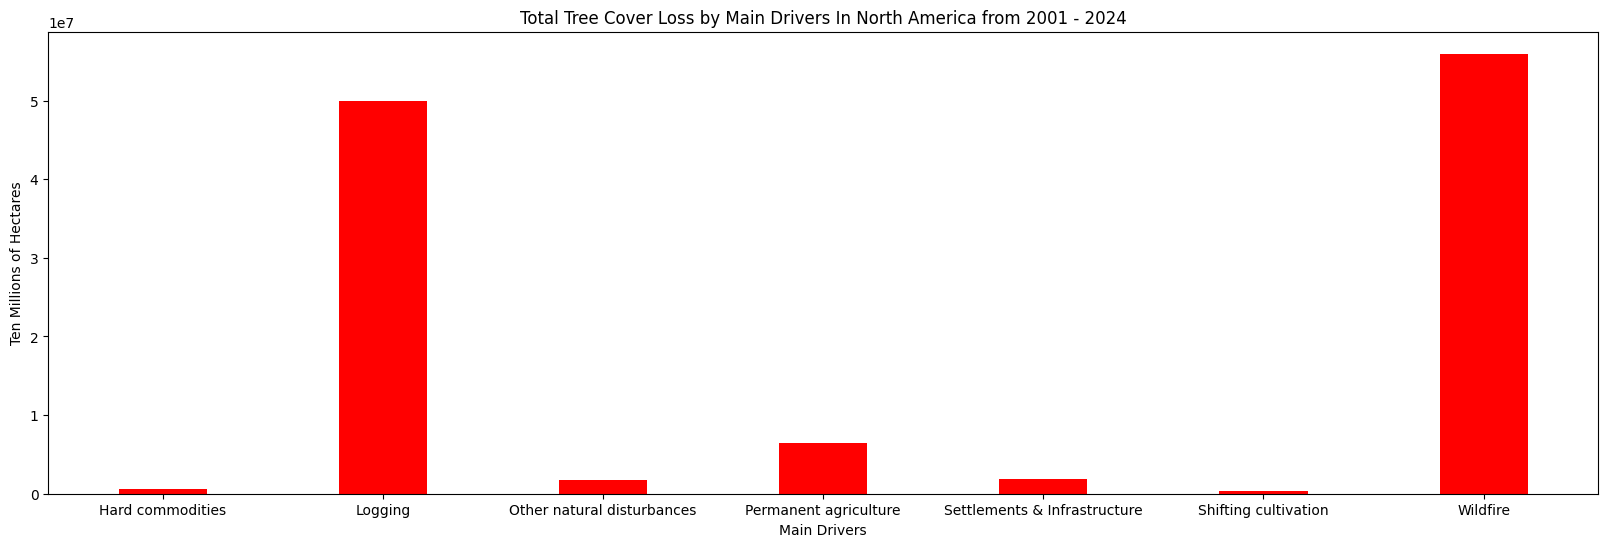

In [ ]:
#Visualization 1

#importing libraries
import seaborn as sns
import matplotlib.pyplot as plt

#What are the main drivers of deforestation and tree cover loss in the North American Countries of Canada, U.S.A., and Mexico?
#Bar Chart of Main Drivers in deforestation for each country and their tree cover loss in hectarage
MainDriverCount= NA_cdr.groupby('driver')['tc_loss_ha'].sum()

#Verifying GroupBy Results
print(MainDriverCount)

#Plotting the chart
plt.figure(figsize=(20,6))
plt.bar(MainDriverCount.index, MainDriverCount.values, color='red', width=0.4)

plt.title('Total Tree Cover Loss by Main Drivers In North America from 2001 - 2024')
plt.xlabel('Main Drivers')
plt.ylabel('Ten Millions of Hectares')

plt.show()

#Visualization 1 Analysis (Bar Graph): What are the main drivers of deforestation and tree cover loss in the North American Countries of Canada, U.S.A., and Mexico?

A hectare is 100 acres. A main driver is the cause of deforestation in the dataset.

1.) For the entire mainland continent of North America, there has been a recorded loss of ~5 Billion acres of forests or tree cover from 2001 to 2024 due to logging alone.

2.) In addition to that there has been a recorded ~5.5 Billion acres lost to wildfires in North America. That is a total of ~10.5 Billion acres (or 4.249199 hectares) of forest loss with those two main driver alone.

3.) The third highest main driver would be Permanent Agriculture developments, but that is much less compared to the other two.

It is noticeable that the top three main drivers for tree cover loss in North America are mostly controllable, best practices.

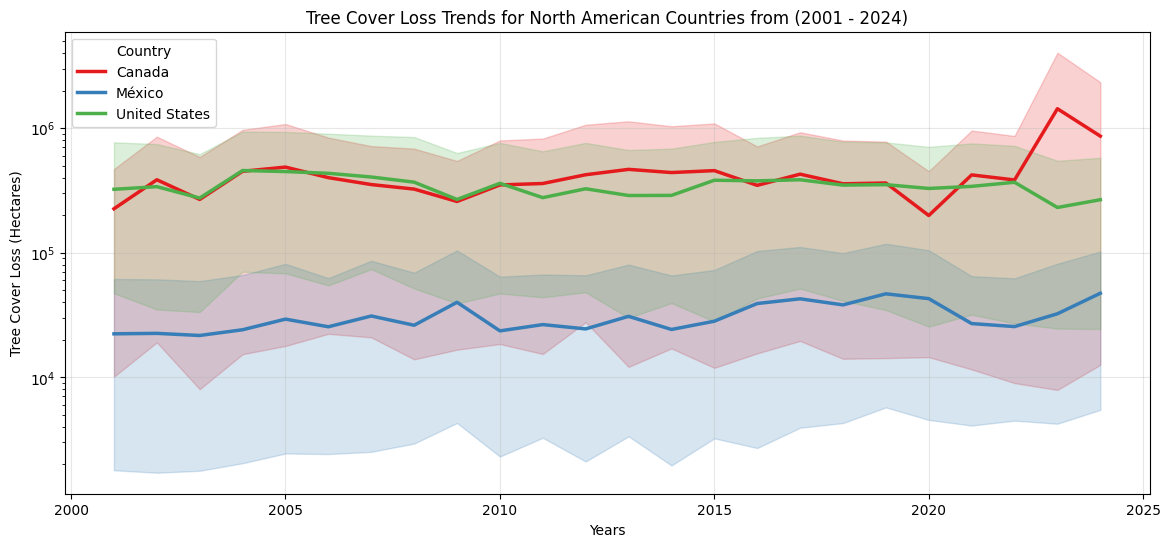

,country,threshold,driver,year,tc_loss_ha
20566,United States,30,Wildfire,2020,687668.0
20567,United States,30,Wildfire,2021,862273.0
20568,United States,30,Wildfire,2022,978021.0
20569,United States,30,Wildfire,2023,301854.0
20570,United States,30,Wildfire,2024,530978.0


In [ ]:
#Visualization 2

#importing libraries
import seaborn as sns
import matplotlib.pyplot as plt

#How do the deforestation trends of these drivers for each country compare to each other?
#Plotting Line Graph
plt.figure(figsize=(14,6))
sns.lineplot(
    data = NA_cdr,
    x='year',
    y='tc_loss_ha',
    hue='country',
    linewidth=2.5,
    palette='Set1'
)
#The range of values in hectares lost was very wide so I had to use a log scale to help visualize the impact
plt.yscale('log')  # Logarithmic scale
plt.grid(alpha=0.3)
plt.legend(title='Country', loc='best')
plt.title('Tree Cover Loss Trends for North American Countries from (2001 - 2024)')
plt.ylabel('Tree Cover Loss (Hectares)')
plt.xlabel('Years')
plt.show()
NA_cdr.tail()


# Visualization 2 Analysis (Line Graph): How do the deforestation trends of these drivers for each country compare to each other?

1.) Depending on actual recorded data, Mexico contrubutes the least to deforestation by hectares in North America. However it is unkown if this dataset takes into account illegal logging which is very prominent in Mexico, and so the data for Mexico may be incomplete.


2.) As for Canada and USA their contribution to forest hectare loss are about the same and steady. This tracks as logging and wildfires are very common in both of these countries.

3.) It isn't until the early 2020s however where Canada has a massive spike in tree cover loss that may be attributed to wildfires. After a quick search the spike for Canada may be attributed to massive wildfire burns in 2023. There is an expected additional spike in the 2025 data once the data is updated due to massive wildfires Canada has been fighting currently.

Next I will compare main drivers for deforestation by each country to confirm my theories.

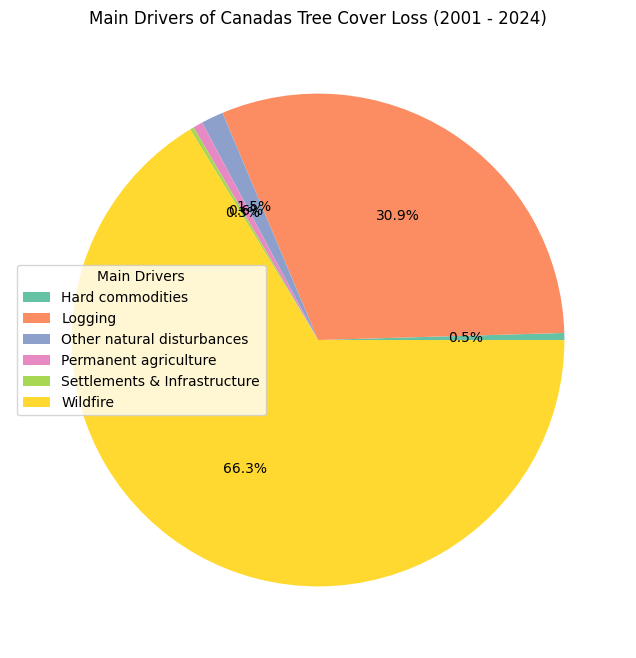

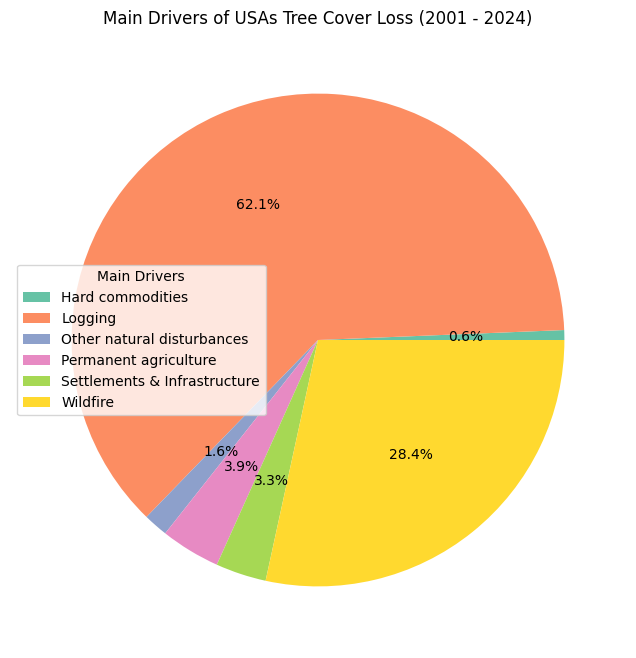

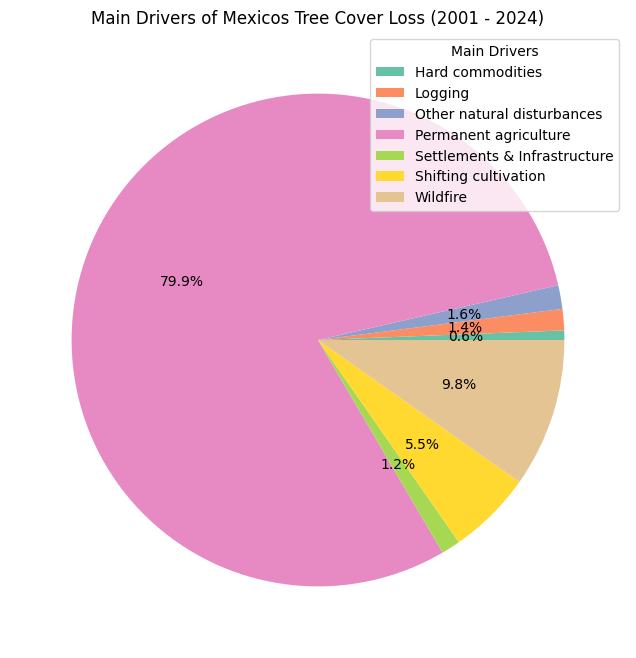

In [ ]:
#Visualization 3

#importing libraries
import seaborn as sns
import matplotlib.pyplot as plt

#What are each North American Countries Main Drivers in Deforestation from 2001 - 2024?

#Canada Grouping Driver & Pie Chart Plotting
CANMDC = CAN_cdr.groupby('driver')['tc_loss_ha'].sum()
plt.figure(figsize=(10, 8))
plt.pie(CANMDC,
        labels= None,
        autopct='%1.1f%%',
        colors= sns.color_palette('Set2'),
)
plt.legend(CANMDC.index, title='Main Drivers', loc='best')
plt.title('Main Drivers of Canadas Tree Cover Loss (2001 - 2024)')
plt.show()

#USA Grouping Drivers & Pie Chart Plotting
USAMDC = USA_cdr.groupby('driver')['tc_loss_ha'].sum()
plt.figure(figsize=(10, 8))
plt.pie(USAMDC,
        labels= None,
        autopct='%1.1f%%',
        colors= sns.color_palette('Set2'),
)
plt.legend(USAMDC.index, title='Main Drivers', loc='best')
plt.title('Main Drivers of USAs Tree Cover Loss (2001 - 2024)')
plt.show()


#Mexico Grouping Drivers & Pie Chart Plotting
MEXMDC = MEX_cdr.groupby('driver')['tc_loss_ha'].sum()
plt.figure(figsize=(10, 8))
plt.pie(MEXMDC,
        labels= None,
        autopct='%1.1f%%',
        colors= sns.color_palette('Set2'),
)
plt.legend(MEXMDC.index, title='Main Drivers', loc='best')
plt.title('Main Drivers of Mexicos Tree Cover Loss (2001 - 2024)')
plt.show()

# Visualization 3 Analysis (Pie Charts): What are each North American Countries Main Drivers in Deforestation from 2001 - 2024?

1.) This confirms my theory that Canada's spike in tree cover loss may have been due to wildfires as that is the largest main driver for the country at 66.3% which is 2/3rds of it's deforestation. The other 1/3 is mostly logging. The causes to these trends may be that Canada has much larger forest land in less developed areas, and so wildfires are more prone to break out and less likely to be controlled as effectively compared to a larger and more urban developed country like the USA.

2.) As for the USA, the main driver is logging at 62.1% with wildfire following second at 28.4%, and other natural disturbances, permanent agriculture, and settlements & infrastructure follow at a higher percentage compared to Canada. These percentages may be attributed to the USA growing as a major lumber exporter after NAFTA was signed into law. As noted in Canada's analysis, perhaps USA's infrastructure allows for wildfires to be controlled and managed more frequently and effectively compared to Canada resulting at a lower percentage as a driver in tree cover loss.

3.) Mexico's graph shows a completely different story with 79.9% of it's tree cover loss being due to permanent agriculture. And wildfires being a distant 2nd at 9.8%. The dataset may be accurate after all since Mexico is facing an illegal logging problem where people harvest a forest, sell the timber illegally, and then clear the land to build farms and infrastructure for crops like Avocado, Lime, and other fruits. This pattern would then explain why logging isn't as large as I expected it to be in the dataset for Mexico when it is not reported as legal logging. Again assuming the dataset and its sources are complete.



# Part 3: Using Machine Learning to predict Deforestation trends in North America

In [ ]:
#Machine Learning Pt 1 - Can we accurately predict future tree cover loss in hectares by year? (Linear Regression)

#Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np


In [ ]:
#Select, Load, Clean Data
print(NA_cdr.shape)
NA_cdr.head()

NA_cdr = NA_cdr.drop_duplicates()
print('Number of Duplicates:', NA_cdr.duplicated().sum())

#Split Train, Test Data
X = NA_cdr[['year']]
y = NA_cdr['tc_loss_ha']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Create Model
lin_reg = LinearRegression()

#Fit Model
lin_reg.fit(X_train, y_train)

#Prediction on Test Data
y_pred = lin_reg.predict(X_test)

#Evaluate Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('MSE:', mse)
print('RMSE:', rmse)

(456, 5)
Number of Duplicates: 0
MSE: 199200758532.5418
RMSE: 446319.12185401807


#Machine Learning Pt 1 Analysis: Can we accurately predict future tree cover loss in hectares by year? (Linear Regression)

Output:

MSE: 199200758532.5418

RMSE: 446319.12185401807

 **Metric Analysis**


---


*Using Claude AI to help Interpret Metrics*


"**MSE (Mean Squared Error)**: The average of the squared differences between predicted and actual values. Lower is better, but the units are squared hectares, making it hard to interpret directly.

**RMSE (Root Mean Squared Error)**: The square root of MSE, which gives you the average prediction error in the original units (hectares). This is more interpretable.

If your RMSE is large (e.g., 200,000+ hectares), your model has poor predictive accuracy
If your RMSE is small relative to your data range, the model predicts reasonably well
Given your data ranges from 467 to 7,789,588 hectares, context matters a lot."


---


This AI interpretation of the Linear Regression Model accuracy was really helpful in understanding how the large units of Hectares in the dataset fit in the MSE and RMSE evaluations.

Since we have such a large range from hundreds of Hectares upto millions of Hectares, the MSE is unable to be interpreted accurately like other model evaluations would be. Since the MSE is squared, I've taken the squared root of it and ended up with 446,319.121. This means the model predicts within an accuracy of an average difference of 446,319.121 Hectares. This difference is very large and therefore my model performs very poorly in predicting Hectarage loss by year in North America.

Ideally we would want the RMSE to be as close to 0 as possible, but considering our large and unpredictable data range I will need to manipulate the data to improve the accuracy and interpretation of boththe MSE and RMSE.

Since the range of tc_loss_ha is so large, I will filter the data to a more managable range.

I will remove the datapoints where the tree cover loss is very low by driver. That means removing rows where 'Hard commodities', 'Other natural disturbances', 'Settlements & Infrastructure', 'Permanent agriculture', and 'Shifting cultivation' are main drivers.

These removed drivers have much lower Hectare loss in comparison to 'Wildfire' and 'Logging'.

And so now my model will shift to:

*Can we accurately predict Tree Cover Loss for Wildfires and Logging in North America by Year?*

In [ ]:
#Machine Learning Pt 1 - Can we accurately predict Tree Cover Loss for Wildires and Logging in North America by Year?

#Manipulate DataFrame
low_drivers = ['Hard commodities', 'Other natural disturbances', 'Settlements & Infrastructure', 'Permanent agriculture', 'Shifting cultivation']

NA_cdr_filtered = NA_cdr[NA_cdr['driver'].isin(low_drivers)] #Removes rows where driver is listed in the list above
print(NA_cdr_filtered.shape) #confirming 144 rows removed from DataFrame

#Split Train, Test Data
X = NA_cdr_filtered[['year']]
y = NA_cdr_filtered['tc_loss_ha']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Create Model
lin_reg = LinearRegression()

#Fit Model
lin_reg.fit(X_train, y_train)

#Prediction on Test Data
y_pred = lin_reg.predict(X_test)

#Evaluate Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('MSE:', mse)
print('RMSE:', rmse)

(312, 5)
MSE: 1839568340.7663336
RMSE: 42890.189330035995


# Machine Learning Pt 1 Analysis: Can we accurately predict Tree Cover Loss for Wildfires and Logging in North America by Year? (Improved Linear Regression Model)

Output:

MSE: 1839568340.7663336

RMSE: 42890.189330035995

 **Metric Analysis**

 It worked! Shortening the range of Tree Cover Loss Hectarage by removing the lowest end of contributers by drivers improved the accuracy of our model by reducing the MSE and RMSE.

 MSE is still uninterpretable, but RMSE tells a different story. Our model correctly predicts Hectarage loss within a 42,890.19 difference which is significantly better than the 446,319 difference from the previous model.

 There is still room for much improvement, but this is a start considering how unpredictable Wildfires can be in contributing to Tree Cover Loss in North America.

 ---

*Using Claude AI to help interpret metrics*

RMSE Reduction:

Went from 446,319 to 42,890 hectares
That's a 90.4% reduction in error! 🎉
Your predictions are now 10.4x more accurate

MSE Reduction:

Went from 199 billion to 1.8 billion
That's a 99.1% reduction (since MSE squares the errors, improvements look even more dramatic)

What This Means
Before:

Average prediction error: ~446,000 hectares
For a loss of 500,000 hectares, prediction could be off by nearly the entire amount
Model was essentially unusable for practical predictions

After:

Average prediction error: ~43,000 hectares
For a loss of 500,000 hectares, prediction is off by only ~9%
Model is now much more reliable

---

In [ ]:
#Machine Learning Pt 2
#Can we accurately predict future wildfires as a main driver in tree cover loss? (Logistic Regression)

#Import Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#Creating Binary Target Variable
NA_cdr['is_wildfire'] = (NA_cdr['driver'] == 'Wildfire').astype(int)

#Select, Load, Clean Data
X = NA_cdr[['year', 'tc_loss_ha']]
y = NA_cdr['is_wildfire']  # Should be categorical (e.g., 0/1, 'Yes'/'No')

#Split Train, Test Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Create Model
log_reg = LogisticRegression(random_state=42, max_iter=1000)

#Fit Model
log_reg.fit(X_train, y_train)

#Prediction on Test Data
y_pred = log_reg.predict(X_test)

#Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print('Accuracy:\n', accuracy)
print('Classification Report\n:', class_report)
print('confusion_matrix:\n', conf_matrix)


Accuracy:
 0.8043478260869565
Classification Report
:               precision    recall  f1-score   support

           0       0.81      0.99      0.89        72
           1       0.75      0.15      0.25        20

    accuracy                           0.80        92
   macro avg       0.78      0.57      0.57        92
weighted avg       0.79      0.80      0.75        92

confusion_matrix:
 [[71  1]
 [17  3]]


#Machine Learning Pt 2 Analysis: Can we accurately predict future wildfires as a main driver in tree cover loss? (Logistic Regression)


This Logistical Regression model predicts whether tree cover loss was caused by wildfire (1) or not (0) based on year and amount of loss.

Output:

Accuracy:
 0.8043478260869565

Classification Report:      

      precision   recall  f1-score   support
           0       0.81      0.99      0.89        72
           1       0.75      0.15      0.25        20

    accuracy                 0.80        92
    macro avg      0.78      0.57      0.57        92
    weighted avg   0.79      0.80      0.75        92

confusion_matrix:

 [[71  1]

 [17  3]]

**Metric Analysis**

The accuracy of the Logistic Regression Model is: 80.4%. Which is pretty good on it's first testing. This means that our model can predict the accuracy of whether Wildfires will be a Main Driver in tree cover loss 80.4% of the time. However, as we look closer at the metrics that is not exactly the case.


---


*Using Claude AI to help interpret metrics*

"[71  1]  - Class 0 (Not Wildfire): 71 correct, 1 wrong

[17  3] - Class 1 (Wildfire): 3 correct, 17 wrong

Class 0 (Not Wildfire):

Precision: 81%

Recall: 99% - It catches 99% of all non-wildfire cases (71 out of 72)
Performance: Excellent

Class 1 (Wildfire):

Precision: 75% - When it predicts "wildfire", it's right 75% of the time
Recall: 15% - It only catches 15% of actual wildfires (3 out of 20)

Performance: Very Poor - It misses 17 out of 20 wildfires!



What this means:
Your model is very conservative - it almost always predicts "not wildfire" because the dataset is imbalanced (72 non-wildfire vs 20 wildfire cases)
The model learned to play it safe by defaulting to the majority class"


---

The AI's interpretation of the metrics data helped me realize that the Logistic Model didn't actually predict wildfire's accurately, but instead accurately predicted non-wildfires very efficiently according to the Confusion Matrix.

Based on the large numbers in the True 'Not Wildfire' predictions in the confusion matrix it seems the data is skewed towards having more non-wildfire incidents in the dataset then not.

Looking more closely, I also realize that my X and y parameters are not actually answering the question I had originally proposed. Why is the 'is Wildfire' condition being predicted by Tree Cover Loss and Year?

As a result I will have to either change my question, change my parameters, or both.

After some reflection I will change my question to:

*Can we accurately predict Wildfire being a Main Driver based on Tree Cover Loss, Country, and Year in North America?*

I will change the X parameters to include 'country' as well to improve the accuracy of my model.

Taking the suggestions of Claude AI I will also:

1. Import a scaling tool to scale the large ranges 'year' and 'tc_loss_ha' have compared to one another.
2. Use pd.getdummies to include 'country' (string) as an X parameter by converting the 'country' values to either '0', '1', or '2' allowing the logistic regression to work correctly.
3. Balance the classes between 'is wildfire' and 'not wildfire' because one shows up much more than the other 'not wildfire'. This addition will help train the model by penalizing the model for getting 'is wildfire' wrong and penalizing it less for getting 'not wildfire' wrong. This urges the model to attempt to get 'is wildfire' right more frequently.
4. Include stratify y to maintain this class balance by keeping an equal ratio of the dataset values ('is wildfire' and 'not wildfire') between the training set and test set.

In [ ]:
#Machine Learning Pt 2
#Can we accurately predict Wildfire being a Main Driver based on Tree Cover Loss, Country, and Year in North America?

#importing Scaling for year and tc_loss_ha
from sklearn.preprocessing import StandardScaler

#Creating Binary Target Variable
NA_cdr['is_wildfire'] = (NA_cdr['driver'] == 'Wildfire').astype(int)


#Select, Load, Clean Data
X = pd.get_dummies(NA_cdr[['country', 'year', 'tc_loss_ha']], columns=['country'], drop_first=True) #adding country as a parameter
y = NA_cdr['is_wildfire']  #(e.g., 0/1, 'Yes'/'No')

#Split Train, Test Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)
#adding class wight balanced and stratify y

#Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Create Model
log_reg = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

#Fit Model
log_reg.fit(X_train_scaled, y_train)

#Prediction on Test Data
y_pred = log_reg.predict(X_test_scaled)

#Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print('Accuracy:\n', accuracy)
print('Classification Report\n:', class_report)
print('confusion_matrix:\n', conf_matrix)


Accuracy:
 0.8043478260869565
Classification Report
:               precision    recall  f1-score   support

           0       0.90      0.86      0.88        77
           1       0.42      0.53      0.47        15

    accuracy                           0.80        92
   macro avg       0.66      0.70      0.68        92
weighted avg       0.83      0.80      0.81        92

confusion_matrix:
 [[66 11]
 [ 7  8]]


# Machine Learning Pt 2 Analysis: Can we accurately predict Wildfire being a Main Driver based on Tree Cover Loss, Country, and Year in North America? (Logistic Regression)

Output:

Accuracy:
 0.8043478260869565

confusion_matrix:

 [[66 11]

 [ 7  8]]

**Metric Analysis**

With the improved Logistic Regression Model, our accuracy remains the same at 80%, but now the confusion matrix looks a little different.

The results of the Confusion Matrix show that we get 66 True 'not wildfire' predictions and 11 False 'not wildfire' predictions. In addition it shows that we got 8 True 'is wildfire' predictions and 7 False 'is wildfire' predictions. Which is an improvement in predicting wildfires, but False Negatives increased for 'not wildfire' as a result.

This proves that the model still performs somewhat poorly in accurately predicting wildfires as a main driver based on country, year, and tree cover loss, and instead only reflects an 80% accuracy because it can more often predict non-wildfires based on the fact that the dataset is skewed toward non-wildfires.

---

*Using Claude AI to help interpret metrics*

Class 1 (Wildfire) - THE IMPROVEMENT:

Recall: 53% (was 15%!) 🎉
Correctly identified: 8 out of 15 wildfires (was only 3 out of 20)
Missed only 7 wildfires (was missing 17)
This is a 3.5x improvement in catching wildfires!

What This Means:
✅ Before: Model caught 15% of wildfires (almost useless for wildfire detection)
✅ Now: Model catches 53% of wildfires (much more useful!)
Trade-off:

You're now getting 11 false alarms (predicting wildfire when it's not) vs. 1 before
But you're missing way fewer actual wildfires (7 vs. 17)

For Your Question: "Can we predict wildfire as a main driver?"

Answer: Somewhat! The model can identify about half of wildfire cases
It's not perfect (53% recall), but it's much better than before (15%)
The precision of 42% means when it predicts wildfire, it's only right 42% of the time

---

From the AI Findings, I do appreciate it's use of recall in understanding the results. A 53% recall means that the model can accurately predict True positives over half of the time from the dataset! That's larger than I expected considering how imbalanced the data was.

As for future improvements there's a lot I can do!

1. I can increase the size of the dataset so that there's a larger sample to train and test the model on. Especially with the results of 2025 that weren't included in this one.

2. I can add more features from a larger dataset or join/merge a related dataset that will allow the model to use more parameters in attempting to make it's predictions.

3. I can pull and transform data from other sources like GIS, government agency datasets, and more to make the dataset cleaner for future training and testing.

Just to name a few!

# Part 4: Conclusion

In conclusion we were successfully able to clean, visualize, analyze, and predict deforestation trends in North America as a continent and by Country (Canada, Mexico, U.S.A.).

We found that:

1.   Logging and Wildfires are the largest contributors to Tree Cover Loss (deforestation) in North America.
2.   With U.S.A. and Canada being the biggest contributors to that loss in the past 24 years.

And that we were able to:

3.   Predict Tree Cover Loss by Wildfire and Logging with an average prediction error of: ~43,000 hectares
4.   Predict Wildfires by Tree Cover Loss, Year, and Country in North America with an 80% accuracy that can be even more improved with more features and a larger, more complete dataframe.


In this process I was able to apply the Data loading, processing, visualizing, analysis, and machine learning skills that I learned at Hack The Hood. Even more so it was really fun being able to tackle a problem I've been wanting to answer for a long time. Using this project in Data Science to help analyze our increasing deforestation issue in North America is just the start. I look forward to how this data can be used to solve the questions that were raised as I continue my own research, education, and goals in creating and using sustainable technology and practices to better our communities.

Thank you!

🌱Kenny Solorio🌱

12-12-2025


